Using 15 features for training: 
loan_amnt
funded_amnt
funded_amnt_inv
int_rate
installment
annual_inc
delinq_2yrs
fico_range_low
fico_range_high
open_acc
pub_rec
revol_bal
total_acc
acc_now_delinq
delinq_amnt
Final weights: 
[ 0.18004026  0.17893951  0.15712962  0.55268731 -0.37770623 -0.23003897
  0.011567   -0.09040296 -0.09040409  0.17299924  0.02577026 -0.07488208
 -0.09665183 -0.00684103  0.00384735]
Final bias: -1.571354571747894
Predicted probabilities (first 5): [0.21415672 0.27073132 0.07983572 0.09219022 0.46930592]
Logistic Regression ROC AUC: 68.51%


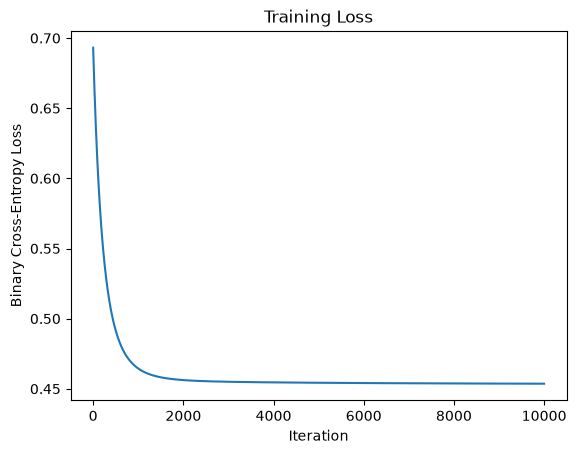

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score

from src.logistic_regression import (
    compute_scaling_params,
    logistic_regression_fit,
    predict,
    scale_features,
)

df_train = pd.read_parquet("data/processed/train.parquet")
df_test = pd.read_parquet("data/processed/test.parquet")


y_train = df_train["target"].copy()
X_train = (
    df_train.drop(columns=["target", "policy_code"])
    .select_dtypes(include="number")
    .copy()
)
feature_cols = X_train.columns[X_train.notna().all()].tolist()
feature_cols_lines = "\n".join(feature_cols)

print(f"Using {len(feature_cols)} features for training: \n{feature_cols_lines}")
X_train = X_train[feature_cols].copy()

y_test = df_test["target"].copy()
X_test = df_test[feature_cols].select_dtypes(include="number").copy()

train_mean, train_std = compute_scaling_params(X_train)

X_train_scaled = scale_features(X_train, train_mean, train_std)
X_test_scaled = scale_features(X_test, train_mean, train_std)


weights, bias, loss = logistic_regression_fit(
    X_train_scaled, y_train, learning_rate=0.01, n_iterations=3000
)

plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss")

print(f"Final weights: \n{weights}")
print(f"Final bias: {bias}")
proba = predict(X_test_scaled, weights, bias)

print(f"Predicted probabilities (first 5): {proba[:5]}")


print(f"Logistic Regression ROC AUC: {roc_auc_score(y_test, proba):.2%}")


# Understanding Week 4

## Logistic Regression Gradient Descent

To predict, we wanted to use logistic regression and gradient descent. Logistic regression is a supervised algorithm used for binary classification, prediction the probability that a data point belongs to a specific class. Gradient descent lets algorithm learn over time and adjust its weights and bias. The loss functions lets us see how the algorithm learns over n iterations.

## Dropping Null Columns

When first trying to train fit the model we passed columns with null in them. This gave the model error. To remove the null columns, did a vectorized pandas check applied across all columns for null values. We only keep columns that do not contain any null values. These are features that we use to train the model.

### Features

- loan_amnt
- funded_amnt
- funded_amnt_inv
- int_rate
- installment
- annual_inc
- delinq_2yrs
- fico_range_low
- fico_range_high
- open_acc
- pub_rec
- revol_bal
- total_acc
- acc_now_delinq
- delinq_amnt

## Standardization

Standardization is to rescale all values into comparable scales so gradient descent converges evenly across all features.

## Findings

We ran our model over 3000 iterations. Our model has a ROC AUC score of 68.53%. This is higher:

- Dummy: 50%
- FICO alone: 59.97%
- Grade alone: 66.97%
- Our logistic regression: 68.53%

This is quite impressive given that we only have 15 features, and we are not using grade nor FICO.
